### 1. colab 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


In [14]:
from sklearn.model_selection import train_test_split
from torchsummary import summary
import torch.optim.lr_scheduler as lr_scheduler

### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class names: {train_dataset.classes}')
print(f'Example image shape: {train_dataset[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [8]:
import torch.nn as nn

class MyCustomBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride, activation=nn.ReLU):
        super(MyCustomBlock,self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,stride,1),
            nn.BatchNorm2d(out_channels),
            activation()
        )

    def forward(self,x):
        out = self.conv(x)

        return out


class MyCustomNet(nn.Module):
    def __init__(self,a=1, activation=nn.ReLU, num_layers=8):
        super(MyCustomNet,self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3,32*a,3,1,1),
            nn.BatchNorm2d(32*a),
            activation()
        )

        self.Mobile = nn.Sequential(
            MyCustomBlock(32*a,64,1, activation),
            MyCustomBlock(64,128,2, activation),
            MyCustomBlock(128,128,1, activation),
            MyCustomBlock(128,128,2, activation),
            MyCustomBlock(128,256,1, activation),
            MyCustomBlock(256,256,2, activation),
            MyCustomBlock(256,256,1, activation),
            nn.AdaptiveAvgPool2d(1)
        )

        # layers 변수에 따라 깊이 조절
        self.Mobile = nn.Sequential(*self.Mobile[:(-1-(8-num_layers))], self.Mobile[-1])
        self.final_channels = [32, 64, 128, 128, 128, 256, 256, 256]

        self.dropout = nn.Dropout(0.5)

        self.FC = nn.Sequential(
            nn.Linear(self.final_channels[num_layers-1],100)
        )

    def forward(self,x):
        out = self.conv1(x)
        out = self.Mobile(out)
        out = out.view(out.size(0),-1)
        out = self.dropout(out)
        out = self.FC(out)

        return out

In [9]:
summary(MyCustomNet(num_layers=1).to(device), (3,32,32))

NameError: name 'summary' is not defined

### 4. train, test 함수 정의

In [10]:
def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)

    model.train()
    epoch_loss , epoch_correct = 0 , 0

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)

        loss = loss_fn(output_, target_)
        loss.backward()
        optimizer.step()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches

In [11]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. log 및 모델 정의

In [12]:
EPOCHS = 30
activation_test_logs = {"ReLU_acc":[],
                        "Sigmoid_acc":[],
                        }

activation_train_logs = {"ReLU_acc":[],
                         "Sigmoid_acc":[],
                         }

model_logs = {"relu_1": {"train_acc": [], "test_acc": []},
              "sigmoid_1": {"train_acc": [], "test_acc": []},
              "relu_2": {"train_acc": [], "test_acc": []},
              "sigmoid_2": {"train_acc": [], "test_acc": []},
              "relu_3": {"train_acc": [], "test_acc": []},
              "sigmoid_3": {"train_acc": [], "test_acc": []},
              "relu_4": {"train_acc": [], "test_acc": []},
              "sigmoid_4": {"train_acc": [], "test_acc": []},
              "relu_5": {"train_acc": [], "test_acc": []},
              "sigmoid_5": {"train_acc": [], "test_acc": []},
              "relu_6": {"train_acc": [], "test_acc": []},
              "sigmoid_6": {"train_acc": [], "test_acc": []},
              "relu_7": {"train_acc": [], "test_acc": []},
              "sigmoid_7": {"train_acc": [], "test_acc": []},
              "relu_8": {"train_acc": [], "test_acc": []},
              "sigmoid_8": {"train_acc": [], "test_acc": []},
              }

models = {
    "relu_1": MyCustomNet(activation=nn.ReLU, num_layers=1).to(device),
    "sigmoid_1": MyCustomNet(activation=nn.Sigmoid, num_layers=1).to(device),
    "relu_2": MyCustomNet(activation=nn.ReLU, num_layers=2).to(device),
    "sigmoid_2": MyCustomNet(activation=nn.Sigmoid, num_layers=2).to(device),
    "relu_3": MyCustomNet(activation=nn.ReLU, num_layers=3).to(device),
    "sigmoid_3": MyCustomNet(activation=nn.Sigmoid, num_layers=3).to(device),
    "relu_4": MyCustomNet(activation=nn.ReLU, num_layers=4).to(device),
    "sigmoid_4": MyCustomNet(activation=nn.Sigmoid, num_layers=4).to(device),
    "relu_5": MyCustomNet(activation=nn.ReLU, num_layers=5).to(device),
    "sigmoid_5": MyCustomNet(activation=nn.Sigmoid, num_layers=5).to(device),
    "relu_6": MyCustomNet(activation=nn.ReLU, num_layers=6).to(device),
    "sigmoid_6": MyCustomNet(activation=nn.Sigmoid, num_layers=6).to(device),
    "relu_7": MyCustomNet(activation=nn.ReLU, num_layers=7).to(device),
    "sigmoid_7": MyCustomNet(activation=nn.Sigmoid, num_layers=7).to(device),
    "relu_8": MyCustomNet(activation=nn.ReLU, num_layers=8).to(device),
    "sigmoid_8": MyCustomNet(activation=nn.Sigmoid, num_layers=8).to(device),
}
models_name = list(models.keys())
criterion = nn.CrossEntropyLoss()

### 6. 학습

In [15]:
from tqdm.notebook import tqdm

# activation별 모델 학습
activation_test_logs_name = list(activation_test_logs.keys())
iteration = 0
for iteration in range(8):
    # ReLU 모델 학습
    current_model = models[f"relu_{iteration+1}"]
    optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print(f'current_model: relu_{iteration+1}')
    print('='*50)
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader, current_model, criterion)
        if(epoch%5 == 0 | epoch == EPOCHS - 1):
            print(f'train_acc:{train_acc:.4f} test_acc:{test_acc:.4f}')
        model_logs[f"relu_{iteration+1}"]["train_acc"].append(train_acc)
        model_logs[f"relu_{iteration+1}"]["test_acc"].append(test_acc)
    
    activation_train_logs["ReLU_acc"].append(train_acc)
    activation_test_logs["ReLU_acc"].append(test_acc)

    # sigmoid 모델 학습
    current_model = models[f"sigmoid_{iteration+1}"]
    optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print(f'current_model: sigmoid_{iteration+1}')
    print('='*50)
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader, current_model, criterion)
        if(epoch%5 == 0 | epoch == EPOCHS - 1):
            print(f'train_acc:{train_acc:.4f} test_acc:{test_acc:.4f}')
        model_logs[f"sigmoid_{iteration+1}"]["train_acc"].append(train_acc)
        model_logs[f"sigmoid_{iteration+1}"]["test_acc"].append(test_acc)

    activation_train_logs["Sigmoid_acc"].append(train_acc)    
    activation_test_logs["Sigmoid_acc"].append(test_acc)

current_model: relu_1


  0%|          | 0/30 [00:00<?, ?it/s]

train_acc:0.0202 test_acc:0.0329
train_acc:0.0492 test_acc:0.0723
train_acc:0.0595 test_acc:0.0786
train_acc:0.0634 test_acc:0.0868
train_acc:0.0647 test_acc:0.0876
train_acc:0.0651 test_acc:0.0873
current_model: sigmoid_1


  0%|          | 0/30 [00:00<?, ?it/s]

train_acc:0.0123 test_acc:0.0309
train_acc:0.0274 test_acc:0.0387
train_acc:0.0305 test_acc:0.0461
train_acc:0.0341 test_acc:0.0475
train_acc:0.0355 test_acc:0.0474
train_acc:0.0363 test_acc:0.0470
current_model: relu_2


...

train_acc:0.0323 test_acc:0.0441
train_acc:0.0880 test_acc:0.1127
train_acc:0.1167 test_acc:0.0723
train_acc:0.1446 test_acc:0.1331
train_acc:0.1732 test_acc:0.1699
train_acc:0.1912 test_acc:0.1651
current_model: relu_8


  0%|          | 0/30 [00:00<?, ?it/s]

train_acc:0.0913 test_acc:0.1422
train_acc:0.3870 test_acc:0.4364
train_acc:0.5142 test_acc:0.5257
train_acc:0.5937 test_acc:0.5749
train_acc:0.6567 test_acc:0.6298
train_acc:0.7007 test_acc:0.6492
current_model: sigmoid_8


  0%|          | 0/30 [00:00<?, ?it/s]

train_acc:0.0321 test_acc:0.0557
train_acc:0.1029 test_acc:0.0690
train_acc:0.1405 test_acc:0.1054
train_acc:0.1856 test_acc:0.1338
train_acc:0.2159 test_acc:0.1561
train_acc:0.2392 test_acc:0.2544


### 7. 시각화

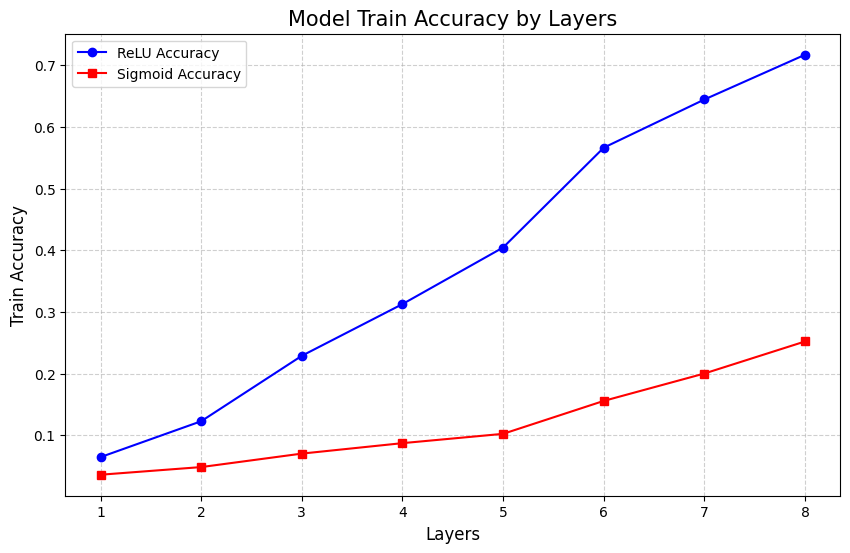

In [16]:
import matplotlib.pyplot as plt

# activation별 모델 정확도 시각화 (Train Accuracy)
plt.figure(figsize=(10, 6))
layers = [1, 2, 3, 4, 5, 6, 7, 8]

plt.plot(layers, activation_train_logs["ReLU_acc"], 'b-o', label='ReLU Accuracy')
plt.plot(layers, activation_train_logs["Sigmoid_acc"], 'r-s', label='Sigmoid Accuracy')
plt.title(f'Model Train Accuracy by Layers', fontsize=15)
plt.xlabel('Layers', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

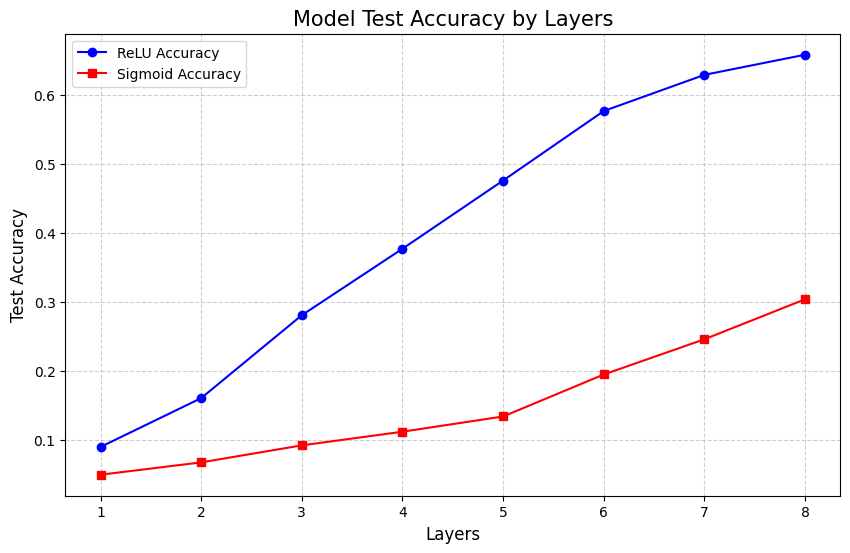

In [17]:
# activation별 모델 정확도 시각화 (Test Accuracy)
plt.figure(figsize=(10, 6))
layers = [1, 2, 3, 4, 5, 6, 7, 8]

plt.plot(layers, activation_test_logs["ReLU_acc"], 'b-o', label='ReLU Accuracy')
plt.plot(layers, activation_test_logs["Sigmoid_acc"], 'r-s', label='Sigmoid Accuracy')
plt.title(f'Model Test Accuracy by Layers', fontsize=15)
plt.xlabel('Layers', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()